In [72]:
import pandas as pd
import pytransit
from matplotlib import pyplot as plt
import numpy as np
from scipy.signal import detrend

In [76]:
df_raw = pd.read_table('WASP-18b.txt')
df_raw

,TIME,SAP_FLUX
0,1354.105952,NaN
1,1354.107340,NaN
2,1354.108729,NaN
3,1354.110118,NaN
4,1354.111507,45699.730
...,...,...
19732,1381.511903,45848.360
19733,1381.513292,45941.605
19734,1381.514681,45924.990
19735,1381.516070,45928.766


In [77]:
df = df_raw[df_raw['SAP_FLUX'].notnull()]
df

,TIME,SAP_FLUX
4,1354.111507,45699.730
5,1354.112896,45753.094
6,1354.114285,45719.250
7,1354.115674,45708.203
8,1354.117063,45696.863
...,...,...
19732,1381.511903,45848.360
19733,1381.513292,45941.605
19734,1381.514681,45924.990
19735,1381.516070,45928.766


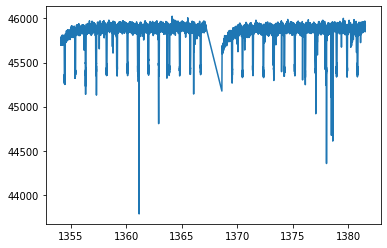

In [79]:
times = np.array(df['TIME'])
fluxes = np.array(df['SAP_FLUX'])
plt.plot(times,fluxes)

In [81]:
lpf = pytransit.lpf.transitlpf.TransitLPF(name='WASP 18b',passbands='data',times=times,fluxes=fluxes)

In [82]:
lpf.print_parameters(columns=1)

  0 |G| tc             N(μ = 0.0, σ = 0.1)                      [    -inf ..      inf]
  1 |G| p              N(μ = 1.0, σ = 1e-05)                    [    0.00 ..      inf]
  2 |G| rho            U(a = 0.1, b = 25.0)                     [    0.00 ..      inf]
  3 |G| b              U(a = 0.0, b = 1.0)                      [    0.00 ..     1.00]
  4 |P| k2             U(a = 0.0025000000000000005, b = 0.04000000000000001) [    0.00 ..      inf]
  5 |P| q1_data        U(a = 0, b = 1)                          [    0.00 ..     1.00]
  6 |P| q2_data        U(a = 0, b = 1)                          [    0.00 ..     1.00]
  7 |L| wn_loge_0      U(a = -4, b = 0)                         [    -inf ..      inf]


Global optimisation:   0%|          | 0/150 [00:00<?, ?it/s]

/usr/local/lib/python3.9/site-packages/pytransit/lpf/lpf.py:416: RuntimeWarning: invalid value encountered in sqrt
  radius_ratio = sqrt(pv[:,4:5])


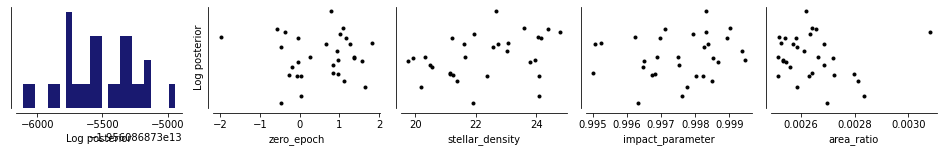

In [83]:
npop         = 30
mcmc_repeats = 4
lpf.optimize_global(150, npop=npop)

(<Figure size 936x288 with 1 Axes>,
 <AxesSubplot:xlabel='Time - 1354 [BJD]', ylabel='Normalised flux'>)

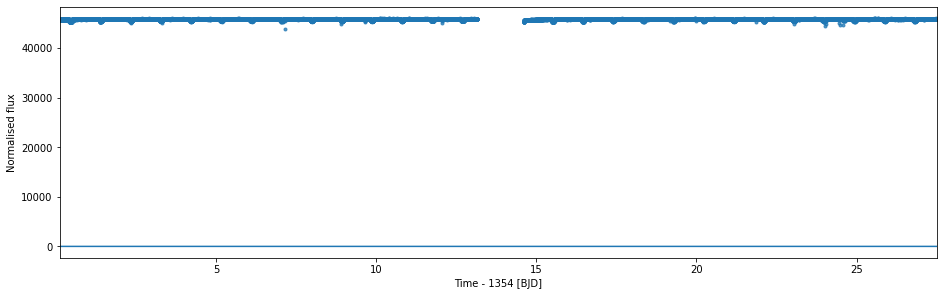

In [84]:
lpf.plot_light_curve()

In [40]:
def flux_baseline():
    return

In [41]:
bl = np.zeros_like(fluxes)

In [42]:
bl

array([0., 0., 0., ..., 0., 0., 0.])

In [92]:
def fold_orbit_and_phase(time, period, origo, shift):
    phase  = ((time - origo) / period + shift)
    orbit  = (phase // 1).astype(int)
    phase  = (phase % 1. - 0.5) * period
    return  orbit, phase

In [94]:
orbit, phase = fold_orbit_and_phase(times,4,2450,0.5)
d_baseline = 0.125           # phase inclusion mask
d_transit = 0.3

In [87]:
msk_phase = abs(phase) < 0.5*d_baseline             # phase inclusion mask
msk_oot   = abs(phase) > 0.5*d_transit              # out-of-transit mask
msk_inc   = np.isfinite(times) & np.isfinite(fluxes) & msk_phase

In [88]:
bl = np.zeros_like(fluxes)
bl[msk_oot] = np.median(fluxes[msk_oot])

In [89]:
len(bl)

18620

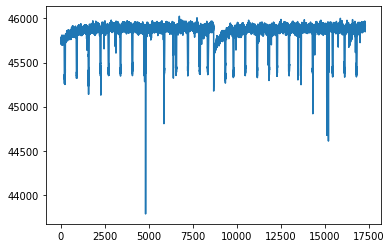

In [90]:
plt.plot(fluxes[msk_oot])